# 3. Registration

Aligning scans: `kabsch` for known correspondences (reflector targets), `icp`
for clouds, and `merge_scans` to bring everything into one frame.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.style.use("sylva.mplstyle")     # shared figure style; C0 to C7 are the Okabe-Ito colours
GROUND, WOOD, LEAF, GRASS, CONTEXT = "#997A5C", "#4D2B12", "#009E73", "#E69F00", "0.8"   # the same in every notebook
DIVERGING = "RdBu_r"                # for signed differences, centred on zero
LABELS = ListedColormap(["#332288", "#88CCEE", "#44AA99", "#117733", "#999933", "#DDCC77",
                         "#CC6677", "#882255", "#AA4499"])   # tree ids and clusters: Paul Tol's muted set

from sylva import filters, registration as reg

Two scans of one synthetic plot (`synthetic.plot`: 20 broadleaf and
eucalypt trees on rough, sloping ground with shrubs, grass, logs and stumps),
each from its own position with the model of a RIEGL VZ-400, 5 mm of range
noise and mixed pixels. Each scan sees its own side of every stem and crown,
so the two clouds overlap only in part, as real scans do. The second is
then moved by a known rigid transform, which registration should undo.

In [2]:
p = synthetic.plot(size=20, density=500, archetypes={"broadleaf": 1, "eucalypt": 1}, seed=1)
scans = []
for k, (x, y) in enumerate([(6, 8), (14, 12)]):
    shots = synthetic.scan(p.points, origin=(x, y, 1.5 + p.ground_height(x, y)), resolution_deg=0.08,
                           scanner="vz400", range_noise=0.005, seed=k)
    scans.append(filters.voxel_downsample(shots.to_pointcloud(), 0.05))
truth = reg.translation(0.6, -0.4, 0.15) @ reg.rotation_z(6.0)
scan_a, scan_b = scans[0], scans[1].transform(np.linalg.inv(truth))
d, _ = filters.knn(scans[0].xyz, scans[1].xyz, 1)
print(f"scan A: {len(scan_a):,} points, scan B: {len(scan_b):,} points (5 cm); "
      f"{np.mean(d[:, 0] < 0.1):.0%} of scan B lies within 10 cm of scan A")

scan A: 508,546 points, scan B: 437,443 points (5 cm); 77% of scan B lies within 10 cm of scan A


## Targets: Kabsch

With matched points the transform is closed-form. Here the targets are
reflectors on the four largest stems at breast height, each located in each
scan with 1 cm of error.

In [3]:
big = np.argsort(p.trees["dbh"])[-4:]
targets_a = np.c_[p.trees["x_bh"][big], p.trees["y_bh"][big], p.trees["z"][big] + 1.3]
rng = np.random.default_rng(0)
targets_b = (np.linalg.inv(truth) @ np.c_[targets_a, np.ones(4)].T).T[:, :3] + rng.normal(0, 0.01, (4, 3))
coarse = reg.kabsch(targets_b, targets_a)


def report(name, T, info=None):
    err = np.linalg.norm((T @ np.linalg.inv(truth))[:3, 3])
    fit = f"rmse {info['rmse']:.4f} m  iterations {info['iterations']:3d}  " if info else ""
    print(f"{name:28s} {fit}translation error {err * 1000:5.1f} mm")


report("targets", coarse)

targets                      translation error  20.0 mm


## Clouds: ICP

ICP refines a starting guess as long as it lies within
`max_correspondence_distance`. From no guess at all (the identity), it gets
within centimetres; point-to-plane converges in fewer iterations, on
surfaces such as ground and stems. From the targets, with a tighter search
distance, it improves on them.

In [4]:
report("point-to-point, identity", *reg.icp(scan_b, scan_a, max_correspondence_distance=1.0))
report("point-to-plane, identity", *reg.icp(scan_b, scan_a, max_correspondence_distance=1.0, method="plane"))
report("point-to-plane, targets", *reg.icp(scan_b, scan_a, init=coarse, max_correspondence_distance=0.3, method="plane"))

point-to-point, identity     rmse 0.1458 m  iterations  45  translation error  35.8 mm


point-to-plane, identity     rmse 0.1454 m  iterations  22  translation error  12.3 mm


point-to-plane, targets      rmse 0.0777 m  iterations   4  translation error   9.4 mm


## Partial overlap

What one scan sees and the other does not (the far side of a stem, a crown
seen only from below) drags the solution: those points are paired with
whatever lies nearest, which is the wrong surface. `trim` keeps only the
closest fraction of correspondences each iteration. Trimming throws
information away, so start it from a coarse alignment (targets, or an
untrimmed run): from far off, the closest pairs are all on the ground and
the solution can slide along it.

In [5]:
T, info = reg.icp(scan_b, scan_a, init=coarse, max_correspondence_distance=0.3, method="plane", trim=0.7)
report("point-to-plane, trim 0.7", T, info)

point-to-plane, trim 0.7     rmse 0.0305 m  iterations   6  translation error   0.9 mm


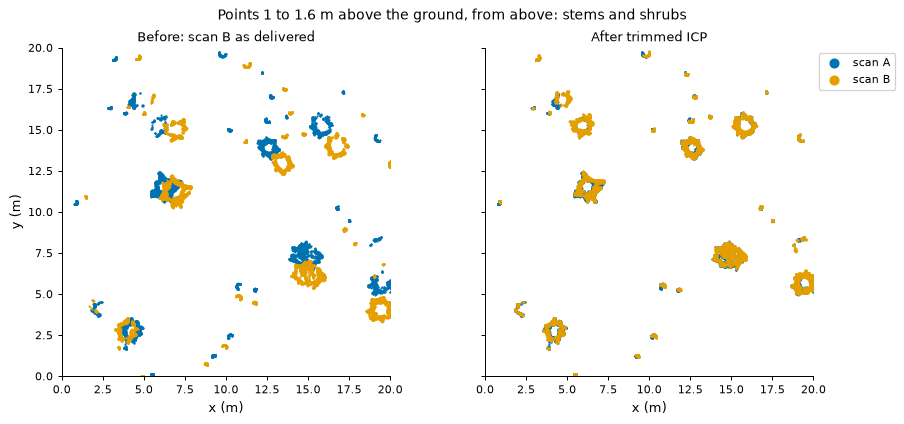

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.6), sharex=True, sharey=True)
for a, b, title in ((ax[0], scan_b, "Before: scan B as delivered"), (ax[1], scan_b.transform(T), "After trimmed ICP")):
    for c, colour, name in ((scan_a, "C0", "scan A"), (b, "C1", "scan B")):
        band = (c.z > p.ground_height(c.x, c.y) + 1.0) & (c.z < p.ground_height(c.x, c.y) + 1.6)   # stems at breast height
        a.scatter(c.x[band], c.y[band], s=0.5, c=colour, label=name)
    a.set(title=title, aspect="equal", xlabel="x (m)", xlim=(0, 20), ylim=(0, 20))
ax[0].set_ylabel("y (m)")
ax[1].legend(markerscale=10, loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.suptitle("Points 1 to 1.6 m above the ground, from above: stems and shrubs");

No untrimmed run gets much below a centimetre, wherever it starts:
a fifth of scan B has no counterpart in scan A, and those points pull the
solution towards the wrong surfaces. Trimmed and started from the targets,
ICP comes within a millimetre of the true transform, well inside the 5 mm
range noise.

## Merging

`merge_scans` applies one transform per scan and records where each point came from.

In [7]:
merged = reg.merge_scans([scan_a, scan_b], [np.eye(4), T])
print(merged.without(*[a for a in merged.attrs if a != "scan_id"]), np.bincount(merged.attrs["scan_id"]))

PointCloud(n=945,989, attrs=['scan_id']) [508546 437443]
